In [1]:
import pandas as pd
import numpy as np

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt

In [2]:
train_data = pd.read_csv("../data/processed/train_data.csv")
test_data = pd.read_csv("../data/processed/test_data.csv")

print("Training shape:", train_data.shape)
print("Testing shape:", test_data.shape)

Training shape: (1600, 12)
Testing shape: (400, 12)


In [3]:
X_train = train_data.drop("Disease_Risk", axis=1)
y_train = train_data["Disease_Risk"]

X_test = test_data.drop("Disease_Risk", axis=1)
y_test = test_data["Disease_Risk"]

In [4]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

X_train: (1600, 11)
X_test: (400, 11)


In [5]:
model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

In [6]:
model.fit(X_train, y_train)

print("Model training completed!")

Model training completed!


In [7]:
y_pred = model.predict(X_test)

In [8]:
y_probability = model.predict_proba(X_test)[:, 1]

In [9]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.8975


In [10]:
print("Accuracy:", round(accuracy * 100, 2), "%")

Accuracy: 89.75 %


In [11]:
precision = precision_score(y_test, y_pred)

print("Precision:", round(precision, 4))

Precision: 0.9257


In [12]:
recall = recall_score(y_test, y_pred)

print("Recall:", round(recall, 4))

Recall: 0.9352


In [13]:
f1 = f1_score(y_test, y_pred)

print("F1 Score:", round(f1, 4))

F1 Score: 0.9304


In [14]:
roc_auc = roc_auc_score(y_test, y_probability)

print("ROC-AUC:", round(roc_auc, 4))

ROC-AUC: 0.9593


In [15]:
print("===== MODEL PERFORMANCE =====")

print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1 Score :", round(f1, 4))
print("ROC-AUC  :", round(roc_auc, 4))

===== MODEL PERFORMANCE =====
Accuracy : 0.8975
Precision: 0.9257
Recall   : 0.9352
F1 Score : 0.9304
ROC-AUC  : 0.9593


In [16]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.82      0.79      0.81       107
           1       0.93      0.94      0.93       293

    accuracy                           0.90       400
   macro avg       0.87      0.86      0.87       400
weighted avg       0.90      0.90      0.90       400



In [17]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[ 85  22]
 [ 19 274]]


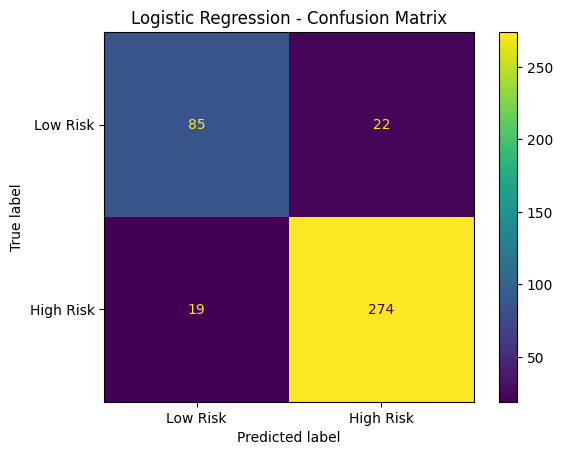

In [18]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Low Risk", "High Risk"]
)

disp.plot()

plt.title("Logistic Regression - Confusion Matrix")
plt.show()

In [19]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": model.coef_[0]
})

feature_importance["Absolute_Coefficient"] = (
    feature_importance["Coefficient"].abs()
)

feature_importance = feature_importance.sort_values(
    "Absolute_Coefficient",
    ascending=False
)

feature_importance

,Feature,Coefficient,Absolute_Coefficient
10,FamilyHistory_Yes,1.835244,1.835244
7,Smoking_Yes,1.769926,1.769926
4,Glucose,1.578478,1.578478
1,BMI,1.555701,1.555701
3,Cholesterol,1.459859,1.459859
0,Age,1.452053,1.452053
2,BloodPressure,1.404580,1.404580
5,HeartRate,0.143077,0.143077
9,PhysicalActivity_Medium,-0.109704,0.109704
6,Gender_Male,-0.020074,0.020074


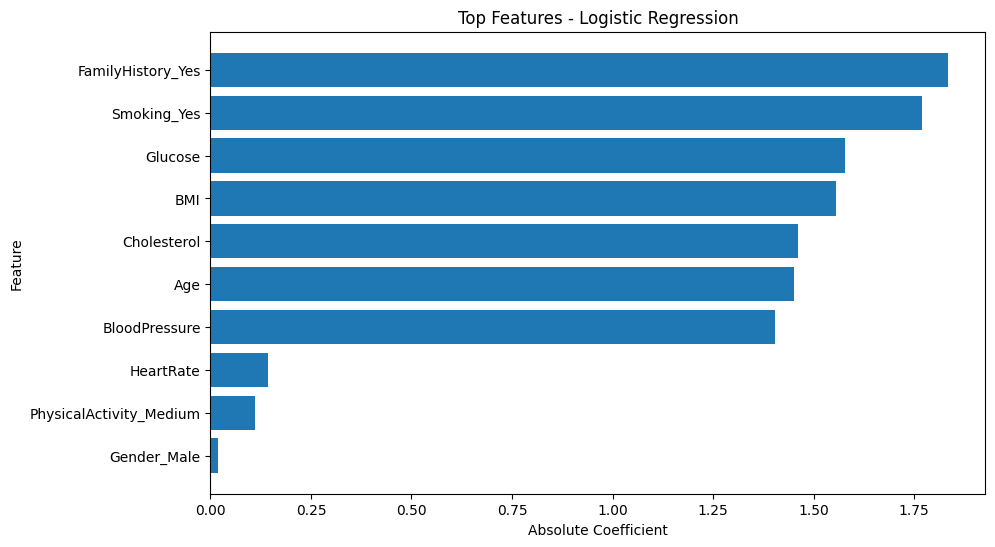

In [20]:
top_features = feature_importance.head(10)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["Feature"],
    top_features["Absolute_Coefficient"]
)

plt.xlabel("Absolute Coefficient")
plt.ylabel("Feature")
plt.title("Top Features - Logistic Regression")

plt.gca().invert_yaxis()

plt.show()

In [21]:
from sklearn.tree import DecisionTreeClassifier

In [22]:
decision_tree = DecisionTreeClassifier(
    random_state=42,
    max_depth=5
)

In [23]:
decision_tree.fit(X_train, y_train)

print("Decision Tree training completed!")

Decision Tree training completed!


In [24]:
dt_pred = decision_tree.predict(X_test)

In [25]:
dt_probability = decision_tree.predict_proba(X_test)[:, 1]

In [26]:
dt_accuracy = accuracy_score(y_test, dt_pred)
dt_precision = precision_score(y_test, dt_pred)
dt_recall = recall_score(y_test, dt_pred)
dt_f1 = f1_score(y_test, dt_pred)
dt_roc_auc = roc_auc_score(y_test, dt_probability)

print("===== DECISION TREE PERFORMANCE =====")

print("Accuracy :", round(dt_accuracy, 4))
print("Precision:", round(dt_precision, 4))
print("Recall   :", round(dt_recall, 4))
print("F1 Score :", round(dt_f1, 4))
print("ROC-AUC  :", round(dt_roc_auc, 4))

===== DECISION TREE PERFORMANCE =====
Accuracy : 0.8725
Precision: 0.8854
Recall   : 0.9488
F1 Score : 0.916
ROC-AUC  : 0.9006


In [27]:
print(classification_report(y_test, dt_pred))

              precision    recall  f1-score   support

           0       0.83      0.66      0.74       107
           1       0.89      0.95      0.92       293

    accuracy                           0.87       400
   macro avg       0.86      0.81      0.83       400
weighted avg       0.87      0.87      0.87       400



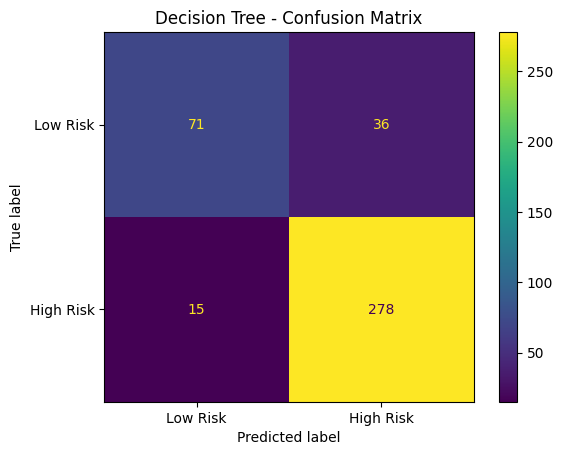

In [28]:
dt_cm = confusion_matrix(y_test, dt_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=dt_cm,
    display_labels=["Low Risk", "High Risk"]
)

disp.plot()

plt.title("Decision Tree - Confusion Matrix")
plt.show()

In [29]:
dt_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": decision_tree.feature_importances_
})

dt_importance = dt_importance.sort_values(
    "Importance",
    ascending=False
)

dt_importance

,Feature,Importance
3,Cholesterol,0.188658
4,Glucose,0.168145
0,Age,0.152543
2,BloodPressure,0.147117
10,FamilyHistory_Yes,0.135142
7,Smoking_Yes,0.118318
1,BMI,0.090077
6,Gender_Male,0.000000
5,HeartRate,0.000000
8,PhysicalActivity_Low,0.000000


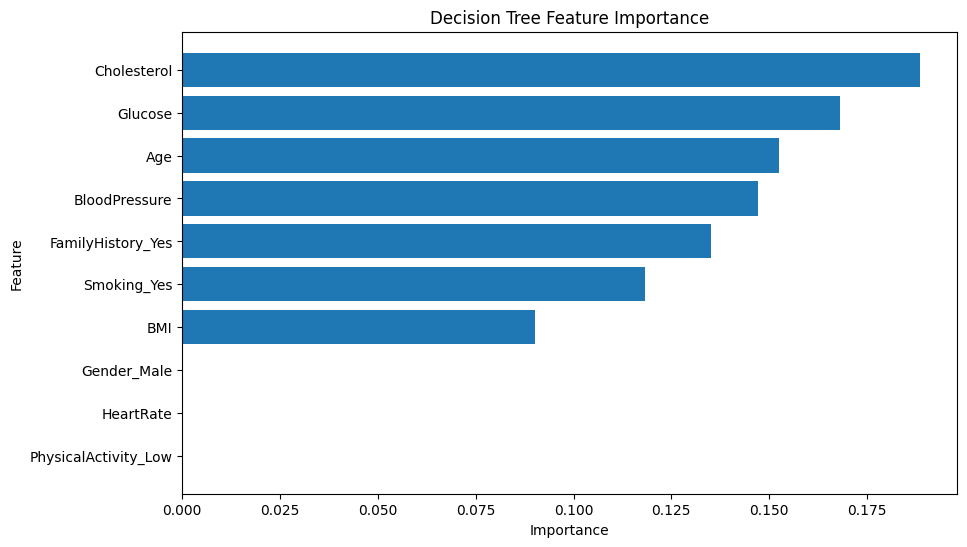

In [30]:
top_dt_features = dt_importance.head(10)

plt.figure(figsize=(10, 6))

plt.barh(
    top_dt_features["Feature"],
    top_dt_features["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Decision Tree Feature Importance")

plt.gca().invert_yaxis()

plt.show()

In [31]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree"
    ],
    "Accuracy": [
        accuracy,
        dt_accuracy
    ],
    "Precision": [
        precision,
        dt_precision
    ],
    "Recall": [
        recall,
        dt_recall
    ],
    "F1 Score": [
        f1,
        dt_f1
    ],
    "ROC-AUC": [
        roc_auc,
        dt_roc_auc
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.8975,0.925676,0.935154,0.93039,0.959300
1,Decision Tree,0.8725,0.885350,0.948805,0.91598,0.900609


In [32]:
from sklearn.ensemble import RandomForestClassifier

In [33]:
random_forest = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    max_depth=10,
    min_samples_split=5,
    n_jobs=-1
)

In [34]:
random_forest.fit(X_train, y_train)

print("Random Forest training completed!")

Random Forest training completed!


In [35]:
rf_pred = random_forest.predict(X_test)

In [36]:
rf_probability = random_forest.predict_proba(X_test)[:, 1]

In [37]:
rf_accuracy = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred)
rf_recall = recall_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)
rf_roc_auc = roc_auc_score(y_test, rf_probability)

print("===== RANDOM FOREST PERFORMANCE =====")

print("Accuracy :", round(rf_accuracy, 4))
print("Precision:", round(rf_precision, 4))
print("Recall   :", round(rf_recall, 4))
print("F1 Score :", round(rf_f1, 4))
print("ROC-AUC  :", round(rf_roc_auc, 4))

===== RANDOM FOREST PERFORMANCE =====
Accuracy : 0.9525
Precision: 0.9477
Recall   : 0.9898
F1 Score : 0.9683
ROC-AUC  : 0.9945


In [38]:
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.97      0.85      0.91       107
           1       0.95      0.99      0.97       293

    accuracy                           0.95       400
   macro avg       0.96      0.92      0.94       400
weighted avg       0.95      0.95      0.95       400



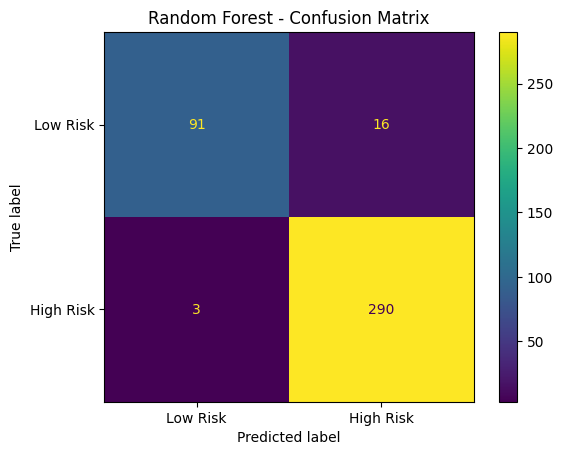

In [39]:
rf_cm = confusion_matrix(y_test, rf_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=rf_cm,
    display_labels=["Low Risk", "High Risk"]
)

disp.plot()

plt.title("Random Forest - Confusion Matrix")
plt.show()

In [40]:
rf_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": random_forest.feature_importances_
})

rf_importance = rf_importance.sort_values(
    "Importance",
    ascending=False
)

rf_importance

,Feature,Importance
4,Glucose,0.164677
3,Cholesterol,0.157094
1,BMI,0.139619
0,Age,0.136177
2,BloodPressure,0.135885
10,FamilyHistory_Yes,0.107468
7,Smoking_Yes,0.092024
5,HeartRate,0.045559
8,PhysicalActivity_Low,0.008310
9,PhysicalActivity_Medium,0.007510


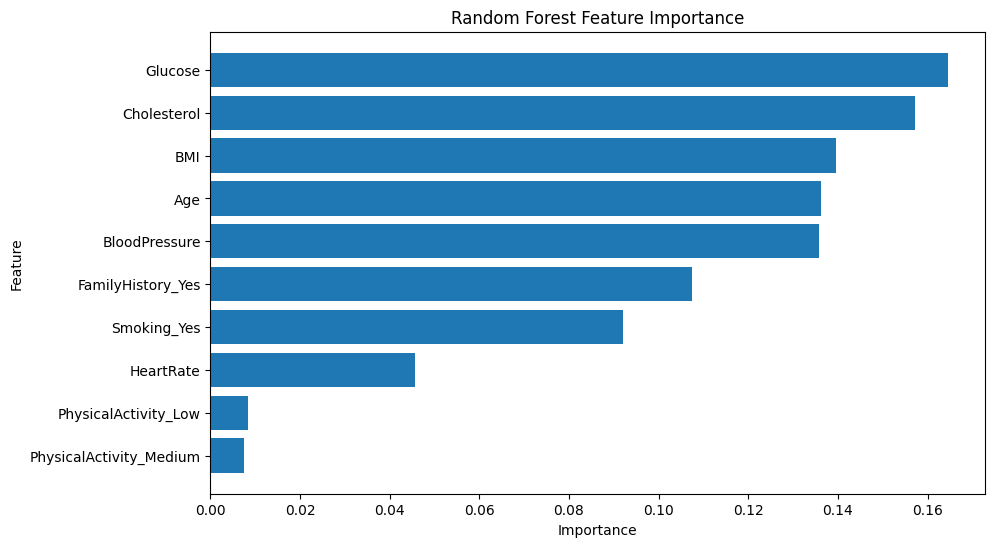

In [41]:
top_rf_features = rf_importance.head(10)

plt.figure(figsize=(10, 6))

plt.barh(
    top_rf_features["Feature"],
    top_rf_features["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")

plt.gca().invert_yaxis()

plt.show()

In [42]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy,
        dt_accuracy,
        rf_accuracy
    ],
    "Precision": [
        precision,
        dt_precision,
        rf_precision
    ],
    "Recall": [
        recall,
        dt_recall,
        rf_recall
    ],
    "F1 Score": [
        f1,
        dt_f1,
        rf_f1
    ],
    "ROC-AUC": [
        roc_auc,
        dt_roc_auc,
        rf_roc_auc
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.8975,0.925676,0.935154,0.93039,0.959300
1,Decision Tree,0.8725,0.885350,0.948805,0.91598,0.900609
2,Random Forest,0.9525,0.947712,0.989761,0.96828,0.994546


In [43]:
from sklearn.ensemble import GradientBoostingClassifier

In [44]:
gradient_boosting = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

In [45]:
gradient_boosting.fit(X_train, y_train)

print("Gradient Boosting training completed!")

Gradient Boosting training completed!


In [46]:
gb_pred = gradient_boosting.predict(X_test)

In [47]:
gb_probability = gradient_boosting.predict_proba(X_test)[:, 1]

In [48]:
gb_accuracy = accuracy_score(y_test, gb_pred)
gb_precision = precision_score(y_test, gb_pred)
gb_recall = recall_score(y_test, gb_pred)
gb_f1 = f1_score(y_test, gb_pred)
gb_roc_auc = roc_auc_score(y_test, gb_probability)

print("===== GRADIENT BOOSTING PERFORMANCE =====")

print("Accuracy :", round(gb_accuracy, 4))
print("Precision:", round(gb_precision, 4))
print("Recall   :", round(gb_recall, 4))
print("F1 Score :", round(gb_f1, 4))
print("ROC-AUC  :", round(gb_roc_auc, 4))

===== GRADIENT BOOSTING PERFORMANCE =====
Accuracy : 0.9875
Precision: 0.9865
Recall   : 0.9966
F1 Score : 0.9915
ROC-AUC  : 0.9997


In [49]:
print(classification_report(y_test, gb_pred))

              precision    recall  f1-score   support

           0       0.99      0.96      0.98       107
           1       0.99      1.00      0.99       293

    accuracy                           0.99       400
   macro avg       0.99      0.98      0.98       400
weighted avg       0.99      0.99      0.99       400



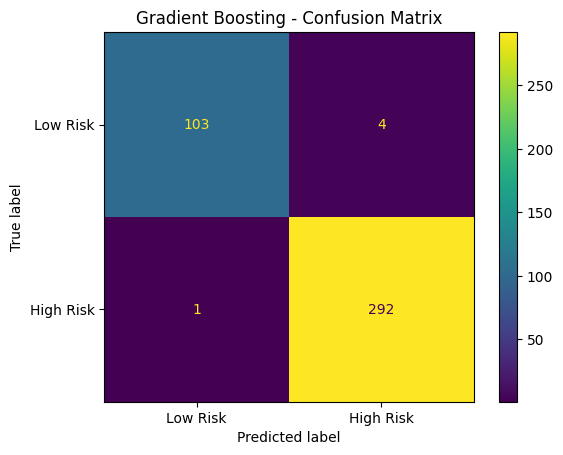

In [50]:
gb_cm = confusion_matrix(y_test, gb_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=gb_cm,
    display_labels=["Low Risk", "High Risk"]
)

disp.plot()

plt.title("Gradient Boosting - Confusion Matrix")
plt.show()

In [51]:
gb_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": gradient_boosting.feature_importances_
})

gb_importance = gb_importance.sort_values(
    "Importance",
    ascending=False
)

gb_importance

,Feature,Importance
4,Glucose,0.161754
3,Cholesterol,0.159993
1,BMI,0.145099
7,Smoking_Yes,0.136576
10,FamilyHistory_Yes,0.136456
2,BloodPressure,0.130363
0,Age,0.128103
5,HeartRate,0.001605
9,PhysicalActivity_Medium,0.000050
6,Gender_Male,0.000000


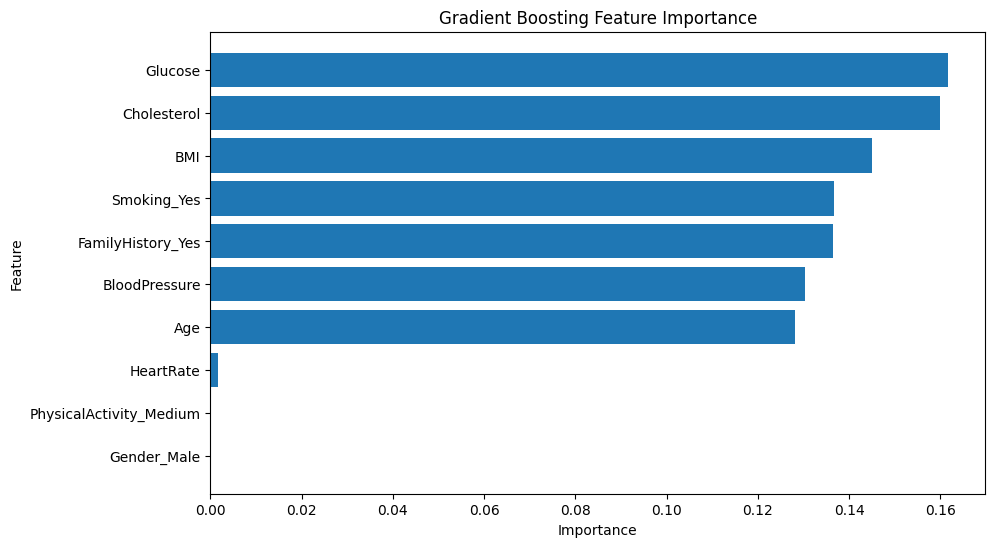

In [52]:
top_gb_features = gb_importance.head(10)

plt.figure(figsize=(10, 6))

plt.barh(
    top_gb_features["Feature"],
    top_gb_features["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Gradient Boosting Feature Importance")

plt.gca().invert_yaxis()

plt.show()

In [53]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting"
    ],
    "Accuracy": [
        accuracy,
        dt_accuracy,
        rf_accuracy,
        gb_accuracy
    ],
    "Precision": [
        precision,
        dt_precision,
        rf_precision,
        gb_precision
    ],
    "Recall": [
        recall,
        dt_recall,
        rf_recall,
        gb_recall
    ],
    "F1 Score": [
        f1,
        dt_f1,
        rf_f1,
        gb_f1
    ],
    "ROC-AUC": [
        roc_auc,
        dt_roc_auc,
        rf_roc_auc,
        gb_roc_auc
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.8975,0.925676,0.935154,0.930390,0.959300
1,Decision Tree,0.8725,0.885350,0.948805,0.915980,0.900609
2,Random Forest,0.9525,0.947712,0.989761,0.968280,0.994546
3,Gradient Boosting,0.9875,0.986486,0.996587,0.991511,0.999745


In [54]:
comparison.sort_values(
    by="ROC-AUC",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
3,Gradient Boosting,0.9875,0.986486,0.996587,0.991511,0.999745
2,Random Forest,0.9525,0.947712,0.989761,0.968280,0.994546
0,Logistic Regression,0.8975,0.925676,0.935154,0.930390,0.959300
1,Decision Tree,0.8725,0.885350,0.948805,0.915980,0.900609


In [55]:
from xgboost import XGBClassifier

In [56]:
xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)

In [57]:
xgb_model.fit(X_train, y_train)

print("XGBoost training completed!")

XGBoost training completed!


In [58]:
xgb_pred = xgb_model.predict(X_test)

In [59]:
xgb_probability = xgb_model.predict_proba(X_test)[:, 1]

In [60]:
xgb_accuracy = accuracy_score(y_test, xgb_pred)
xgb_precision = precision_score(y_test, xgb_pred)
xgb_recall = recall_score(y_test, xgb_pred)
xgb_f1 = f1_score(y_test, xgb_pred)
xgb_roc_auc = roc_auc_score(y_test, xgb_probability)

print("===== XGBOOST PERFORMANCE =====")

print("Accuracy :", round(xgb_accuracy, 4))
print("Precision:", round(xgb_precision, 4))
print("Recall   :", round(xgb_recall, 4))
print("F1 Score :", round(xgb_f1, 4))
print("ROC-AUC  :", round(xgb_roc_auc, 4))

===== XGBOOST PERFORMANCE =====
Accuracy : 0.99
Precision: 0.9898
Recall   : 0.9966
F1 Score : 0.9932
ROC-AUC  : 0.9998


In [61]:
print(classification_report(y_test, xgb_pred))

              precision    recall  f1-score   support

           0       0.99      0.97      0.98       107
           1       0.99      1.00      0.99       293

    accuracy                           0.99       400
   macro avg       0.99      0.98      0.99       400
weighted avg       0.99      0.99      0.99       400



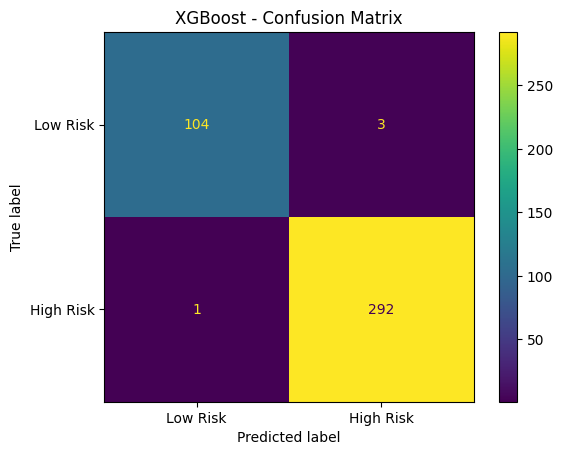

In [62]:
xgb_cm = confusion_matrix(y_test, xgb_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=xgb_cm,
    display_labels=["Low Risk", "High Risk"]
)

disp.plot()

plt.title("XGBoost - Confusion Matrix")
plt.show()

In [63]:
xgb_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": xgb_model.feature_importances_
})

xgb_importance = xgb_importance.sort_values(
    "Importance",
    ascending=False
)

xgb_importance

,Feature,Importance
7,Smoking_Yes,0.178595
10,FamilyHistory_Yes,0.161118
1,BMI,0.136032
3,Cholesterol,0.132759
4,Glucose,0.122446
2,BloodPressure,0.115759
0,Age,0.109841
8,PhysicalActivity_Low,0.015431
5,HeartRate,0.013645
9,PhysicalActivity_Medium,0.009030


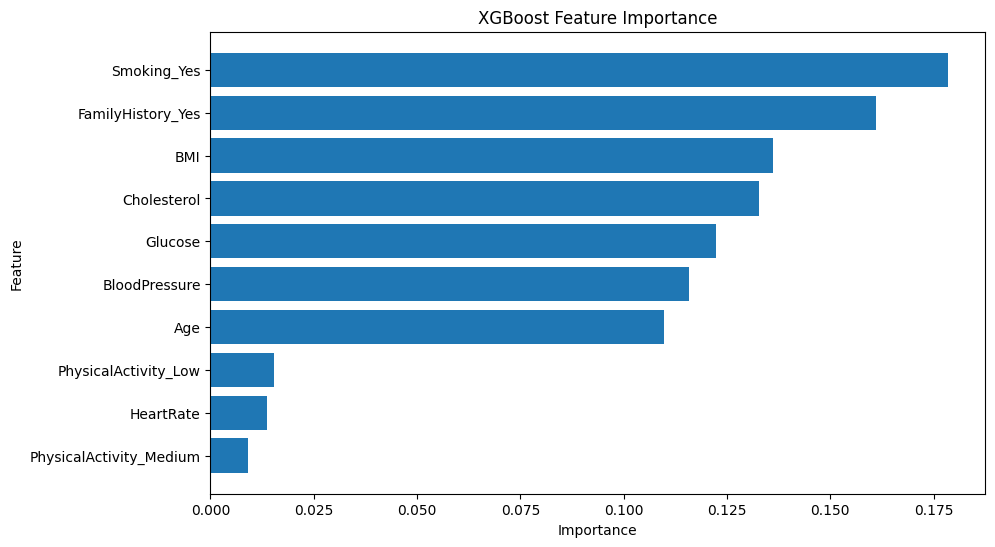

In [64]:
top_xgb_features = xgb_importance.head(10)

plt.figure(figsize=(10, 6))

plt.barh(
    top_xgb_features["Feature"],
    top_xgb_features["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("XGBoost Feature Importance")

plt.gca().invert_yaxis()

plt.show()

In [65]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting",
        "XGBoost"
    ],
    "Accuracy": [
        accuracy,
        dt_accuracy,
        rf_accuracy,
        gb_accuracy,
        xgb_accuracy
    ],
    "Precision": [
        precision,
        dt_precision,
        rf_precision,
        gb_precision,
        xgb_precision
    ],
    "Recall": [
        recall,
        dt_recall,
        rf_recall,
        gb_recall,
        xgb_recall
    ],
    "F1 Score": [
        f1,
        dt_f1,
        rf_f1,
        gb_f1,
        xgb_f1
    ],
    "ROC-AUC": [
        roc_auc,
        dt_roc_auc,
        rf_roc_auc,
        gb_roc_auc,
        xgb_roc_auc
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.8975,0.925676,0.935154,0.930390,0.959300
1,Decision Tree,0.8725,0.885350,0.948805,0.915980,0.900609
2,Random Forest,0.9525,0.947712,0.989761,0.968280,0.994546
3,Gradient Boosting,0.9875,0.986486,0.996587,0.991511,0.999745
4,XGBoost,0.9900,0.989831,0.996587,0.993197,0.999777


In [66]:
comparison_sorted = comparison.sort_values(
    by="ROC-AUC",
    ascending=False
)

comparison_sorted

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
4,XGBoost,0.9900,0.989831,0.996587,0.993197,0.999777
3,Gradient Boosting,0.9875,0.986486,0.996587,0.991511,0.999745
2,Random Forest,0.9525,0.947712,0.989761,0.968280,0.994546
0,Logistic Regression,0.8975,0.925676,0.935154,0.930390,0.959300
1,Decision Tree,0.8725,0.885350,0.948805,0.915980,0.900609


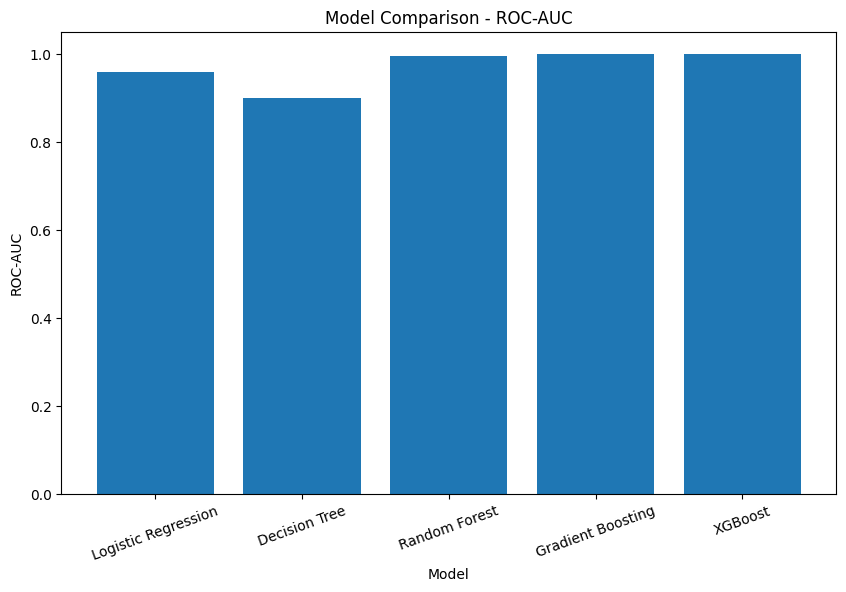

In [67]:
plt.figure(figsize=(10, 6))

plt.bar(
    comparison["Model"],
    comparison["ROC-AUC"]
)

plt.title("Model Comparison - ROC-AUC")
plt.xlabel("Model")
plt.ylabel("ROC-AUC")

plt.xticks(rotation=20)

plt.show()

In [68]:
from sklearn.model_selection import StratifiedKFold, cross_validate

In [69]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [70]:
scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

In [71]:
lr_cv = cross_validate(
    model,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

In [72]:
print("Logistic Regression")
print("Accuracy:", lr_cv["test_accuracy"].mean())
print("Precision:", lr_cv["test_precision"].mean())
print("Recall:", lr_cv["test_recall"].mean())
print("F1:", lr_cv["test_f1"].mean())
print("ROC-AUC:", lr_cv["test_roc_auc"].mean())

Logistic Regression
Accuracy: 0.905
Precision: 0.9250692145903157
Recall: 0.9470558283324241
F1: 0.9358260527563381
ROC-AUC: 0.9595556306842508


In [73]:
dt_cv = cross_validate(
    decision_tree,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

print("Decision Tree")
print("Accuracy:", dt_cv["test_accuracy"].mean())
print("Precision:", dt_cv["test_precision"].mean())
print("Recall:", dt_cv["test_recall"].mean())
print("F1:", dt_cv["test_f1"].mean())
print("ROC-AUC:", dt_cv["test_roc_auc"].mean())

Decision Tree
Accuracy: 0.884375
Precision: 0.9019314433396369
Recall: 0.9453464266230224
F1: 0.9228964036459513
ROC-AUC: 0.9055493977390243


In [74]:
rf_cv = cross_validate(
    random_forest,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

print("Random Forest")
print("Accuracy:", rf_cv["test_accuracy"].mean())
print("Precision:", rf_cv["test_precision"].mean())
print("Recall:", rf_cv["test_recall"].mean())
print("F1:", rf_cv["test_f1"].mean())
print("ROC-AUC:", rf_cv["test_roc_auc"].mean())

Random Forest
Accuracy: 0.9487500000000001
Precision: 0.9382218430134002
Recall: 0.9957374068012367
F1: 0.9660971139364914
ROC-AUC: 0.9947985239947867


In [75]:
gb_cv = cross_validate(
    gradient_boosting,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

print("Gradient Boosting")
print("Accuracy:", gb_cv["test_accuracy"].mean())
print("Precision:", gb_cv["test_precision"].mean())
print("Recall:", gb_cv["test_recall"].mean())
print("F1:", gb_cv["test_f1"].mean())
print("ROC-AUC:", gb_cv["test_roc_auc"].mean())

Gradient Boosting
Accuracy: 0.990625
Precision: 0.9898799058292328
Recall: 0.997439534460811
F1: 0.9936268285882154
ROC-AUC: 0.9992428296252844


In [76]:
xgb_cv = cross_validate(
    xgb_model,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

print("XGBoost")
print("Accuracy:", xgb_cv["test_accuracy"].mean())
print("Precision:", xgb_cv["test_precision"].mean())
print("Recall:", xgb_cv["test_recall"].mean())
print("F1:", xgb_cv["test_f1"].mean())
print("ROC-AUC:", xgb_cv["test_roc_auc"].mean())

XGBoost
Accuracy: 0.99375
Precision: 0.993209367434285
Recall: 0.9982905982905983
F1: 0.9957392060253548
ROC-AUC: 0.999592303935873


In [77]:
cv_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting",
        "XGBoost"
    ],
    
    "Accuracy": [
        lr_cv["test_accuracy"].mean(),
        dt_cv["test_accuracy"].mean(),
        rf_cv["test_accuracy"].mean(),
        gb_cv["test_accuracy"].mean(),
        xgb_cv["test_accuracy"].mean()
    ],
    
    "Precision": [
        lr_cv["test_precision"].mean(),
        dt_cv["test_precision"].mean(),
        rf_cv["test_precision"].mean(),
        gb_cv["test_precision"].mean(),
        xgb_cv["test_precision"].mean()
    ],
    
    "Recall": [
        lr_cv["test_recall"].mean(),
        dt_cv["test_recall"].mean(),
        rf_cv["test_recall"].mean(),
        gb_cv["test_recall"].mean(),
        xgb_cv["test_recall"].mean()
    ],
    
    "F1 Score": [
        lr_cv["test_f1"].mean(),
        dt_cv["test_f1"].mean(),
        rf_cv["test_f1"].mean(),
        gb_cv["test_f1"].mean(),
        xgb_cv["test_f1"].mean()
    ],
    
    "ROC-AUC": [
        lr_cv["test_roc_auc"].mean(),
        dt_cv["test_roc_auc"].mean(),
        rf_cv["test_roc_auc"].mean(),
        gb_cv["test_roc_auc"].mean(),
        xgb_cv["test_roc_auc"].mean()
    ]
})

cv_results

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.905000,0.925069,0.947056,0.935826,0.959556
1,Decision Tree,0.884375,0.901931,0.945346,0.922896,0.905549
2,Random Forest,0.948750,0.938222,0.995737,0.966097,0.994799
3,Gradient Boosting,0.990625,0.989880,0.997440,0.993627,0.999243
4,XGBoost,0.993750,0.993209,0.998291,0.995739,0.999592


In [78]:
cv_results.sort_values(
    by="ROC-AUC",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
4,XGBoost,0.993750,0.993209,0.998291,0.995739,0.999592
3,Gradient Boosting,0.990625,0.989880,0.997440,0.993627,0.999243
2,Random Forest,0.948750,0.938222,0.995737,0.966097,0.994799
0,Logistic Regression,0.905000,0.925069,0.947056,0.935826,0.959556
1,Decision Tree,0.884375,0.901931,0.945346,0.922896,0.905549


In [79]:
print("XGBoost ROC-AUC scores:")

print(xgb_cv["test_roc_auc"])

print(
    "Mean:",
    round(xgb_cv["test_roc_auc"].mean(), 4)
)

print(
    "Standard Deviation:",
    round(xgb_cv["test_roc_auc"].std(), 4)
)

XGBoost ROC-AUC scores:
[0.99984981 0.9981614  1.         0.99995031 1.        ]
Mean: 0.9996
Standard Deviation: 0.0007


In [80]:
from sklearn.model_selection import RandomizedSearchCV

In [81]:
rf_params = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [5, 10, 15, 20, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2", None]
}

In [82]:
rf_random_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(
        random_state=42,
        n_jobs=-1
    ),
    param_distributions=rf_params,
    n_iter=20,
    scoring="roc_auc",
    cv=5,
    random_state=42,
    n_jobs=-1
)

In [85]:
rf_random_search.fit(X_train, y_train)

print("Random Forest tuning completed!")

Random Forest tuning completed!


In [86]:
print("Best Random Forest Parameters:")
print(rf_random_search.best_params_)

Best Random Forest Parameters:
{'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': 'log2', 'max_depth': None}


In [87]:
print(
    "Best Cross-Validation ROC-AUC:",
    round(rf_random_search.best_score_, 4)
)

Best Cross-Validation ROC-AUC: 0.9948


In [88]:
best_rf = rf_random_search.best_estimator_

print(best_rf)

RandomForestClassifier(max_features='log2', min_samples_leaf=4,
                       n_estimators=300, n_jobs=-1, random_state=42)


In [89]:
xgb_params = {
    "n_estimators": [100, 200, 300, 500],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "max_depth": [3, 4, 5, 6, 8],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "min_child_weight": [1, 3, 5]
}

In [90]:
xgb_random_search = RandomizedSearchCV(
    estimator=XGBClassifier(
        random_state=42,
        eval_metric="logloss"
    ),
    param_distributions=xgb_params,
    n_iter=20,
    scoring="roc_auc",
    cv=5,
    random_state=42,
    n_jobs=-1
)

In [91]:
xgb_random_search.fit(X_train, y_train)

print("XGBoost tuning completed!")

XGBoost tuning completed!


In [92]:
print("Best XGBoost Parameters:")
print(xgb_random_search.best_params_)

Best XGBoost Parameters:
{'subsample': 0.7, 'n_estimators': 500, 'min_child_weight': 5, 'max_depth': 5, 'learning_rate': 0.2, 'colsample_bytree': 0.7}


In [93]:
print(
    "Best Cross-Validation ROC-AUC:",
    round(xgb_random_search.best_score_, 4)
)

Best Cross-Validation ROC-AUC: 1.0


In [94]:
best_xgb = xgb_random_search.best_estimator_

print(best_xgb)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.7, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.2, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=5, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=500, n_jobs=None,
              num_parallel_tree=None, ...)


In [95]:
best_rf_pred = best_rf.predict(X_test)
best_rf_probability = best_rf.predict_proba(X_test)[:, 1]

best_rf_auc = roc_auc_score(
    y_test,
    best_rf_probability
)

best_rf_f1 = f1_score(
    y_test,
    best_rf_pred
)

best_rf_recall = recall_score(
    y_test,
    best_rf_pred
)

print("Tuned Random Forest")
print("ROC-AUC:", round(best_rf_auc, 4))
print("F1 Score:", round(best_rf_f1, 4))
print("Recall:", round(best_rf_recall, 4))

Tuned Random Forest
ROC-AUC: 0.9958
F1 Score: 0.9636
Recall: 0.9932


In [96]:
best_xgb_pred = best_xgb.predict(X_test)
best_xgb_probability = best_xgb.predict_proba(X_test)[:, 1]

best_xgb_auc = roc_auc_score(
    y_test,
    best_xgb_probability
)

best_xgb_f1 = f1_score(
    y_test,
    best_xgb_pred
)

best_xgb_recall = recall_score(
    y_test,
    best_xgb_pred
)

print("Tuned XGBoost")
print("ROC-AUC:", round(best_xgb_auc, 4))
print("F1 Score:", round(best_xgb_f1, 4))
print("Recall:", round(best_xgb_recall, 4))

Tuned XGBoost
ROC-AUC: 1.0
F1 Score: 0.9966
Recall: 0.9966


In [97]:
tuned_comparison = pd.DataFrame({
    "Model": [
        "Random Forest",
        "Tuned Random Forest",
        "XGBoost",
        "Tuned XGBoost"
    ],
    "ROC-AUC": [
        rf_roc_auc,
        best_rf_auc,
        xgb_roc_auc,
        best_xgb_auc
    ],
    "F1 Score": [
        rf_f1,
        best_rf_f1,
        xgb_f1,
        best_xgb_f1
    ],
    "Recall": [
        rf_recall,
        best_rf_recall,
        xgb_recall,
        best_xgb_recall
    ]
})

tuned_comparison.sort_values(
    by="ROC-AUC",
    ascending=False
)

,Model,ROC-AUC,F1 Score,Recall
3,Tuned XGBoost,0.999968,0.996587,0.996587
2,XGBoost,0.999777,0.993197,0.996587
1,Tuned Random Forest,0.995790,0.963576,0.993174
0,Random Forest,0.994546,0.968280,0.989761


In [98]:
rf_random_search.fit(X_train, y_train)

,estimator,RandomForestC...ndom_state=42)
,param_distributions,"{'max_depth': [5, 10, ...], 'max_features': ['sqrt', 'log2', ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,n_iter,20
,scoring,'roc_auc'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [99]:
xgb_random_search.fit(X_train, y_train)

,estimator,"XGBClassifier...ree=None, ...)"
,param_distributions,"{'colsample_bytree': [0.7, 0.8, ...], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 4, ...], 'min_child_weight': [1, 3, ...], ...}"
,n_iter,20
,scoring,'roc_auc'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [100]:
final_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting",
        "XGBoost",
        "Tuned Random Forest",
        "Tuned XGBoost"
    ],
    
    "Accuracy": [
        accuracy,
        dt_accuracy,
        rf_accuracy,
        gb_accuracy,
        xgb_accuracy,
        accuracy_score(y_test, best_rf_pred),
        accuracy_score(y_test, best_xgb_pred)
    ],
    
    "Precision": [
        precision,
        dt_precision,
        rf_precision,
        gb_precision,
        xgb_precision,
        precision_score(y_test, best_rf_pred),
        precision_score(y_test, best_xgb_pred)
    ],
    
    "Recall": [
        recall,
        dt_recall,
        rf_recall,
        gb_recall,
        xgb_recall,
        best_rf_recall,
        best_xgb_recall
    ],
    
    "F1 Score": [
        f1,
        dt_f1,
        rf_f1,
        gb_f1,
        xgb_f1,
        best_rf_f1,
        best_xgb_f1
    ],
    
    "ROC-AUC": [
        roc_auc,
        dt_roc_auc,
        rf_roc_auc,
        gb_roc_auc,
        xgb_roc_auc,
        best_rf_auc,
        best_xgb_auc
    ]
})

final_comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.8975,0.925676,0.935154,0.930390,0.959300
1,Decision Tree,0.8725,0.885350,0.948805,0.915980,0.900609
2,Random Forest,0.9525,0.947712,0.989761,0.968280,0.994546
3,Gradient Boosting,0.9875,0.986486,0.996587,0.991511,0.999745
4,XGBoost,0.9900,0.989831,0.996587,0.993197,0.999777
5,Tuned Random Forest,0.9450,0.935691,0.993174,0.963576,0.995790
6,Tuned XGBoost,0.9950,0.996587,0.996587,0.996587,0.999968


In [101]:
final_ranked = final_comparison.sort_values(
    by="ROC-AUC",
    ascending=False
).reset_index(drop=True)

final_ranked

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Tuned XGBoost,0.9950,0.996587,0.996587,0.996587,0.999968
1,XGBoost,0.9900,0.989831,0.996587,0.993197,0.999777
2,Gradient Boosting,0.9875,0.986486,0.996587,0.991511,0.999745
3,Tuned Random Forest,0.9450,0.935691,0.993174,0.963576,0.995790
4,Random Forest,0.9525,0.947712,0.989761,0.968280,0.994546
5,Logistic Regression,0.8975,0.925676,0.935154,0.930390,0.959300
6,Decision Tree,0.8725,0.885350,0.948805,0.915980,0.900609


In [102]:
best_model_name = final_ranked.loc[0, "Model"]

print("Best Model:", best_model_name)

Best Model: Tuned XGBoost


In [103]:
if best_model_name == "Tuned Random Forest":
    final_model = best_rf

elif best_model_name == "Tuned XGBoost":
    final_model = best_xgb

elif best_model_name == "Random Forest":
    final_model = random_forest

elif best_model_name == "XGBoost":
    final_model = xgb_model

elif best_model_name == "Gradient Boosting":
    final_model = gradient_boosting

elif best_model_name == "Decision Tree":
    final_model = decision_tree

else:
    final_model = model

print("Final model selected:", best_model_name)

Final model selected: Tuned XGBoost


In [104]:
final_pred = final_model.predict(X_test)

final_probability = final_model.predict_proba(X_test)[:, 1]

print("===== FINAL MODEL PERFORMANCE =====")

print(
    "Accuracy:",
    round(accuracy_score(y_test, final_pred), 4)
)

print(
    "Precision:",
    round(precision_score(y_test, final_pred), 4)
)

print(
    "Recall:",
    round(recall_score(y_test, final_pred), 4)
)

print(
    "F1 Score:",
    round(f1_score(y_test, final_pred), 4)
)

print(
    "ROC-AUC:",
    round(roc_auc_score(y_test, final_probability), 4)
)

===== FINAL MODEL PERFORMANCE =====
Accuracy: 0.995
Precision: 0.9966
Recall: 0.9966
F1 Score: 0.9966
ROC-AUC: 1.0


In [105]:
print(
    classification_report(
        y_test,
        final_pred,
        target_names=["Low Risk", "High Risk"]
    )
)

              precision    recall  f1-score   support

    Low Risk       0.99      0.99      0.99       107
   High Risk       1.00      1.00      1.00       293

    accuracy                           0.99       400
   macro avg       0.99      0.99      0.99       400
weighted avg       0.99      0.99      0.99       400



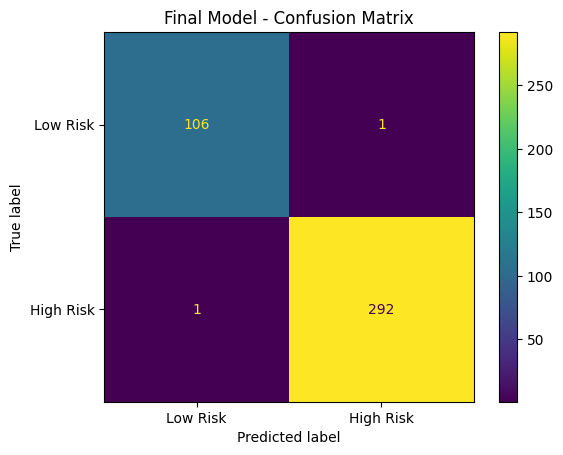

In [106]:
final_cm = confusion_matrix(
    y_test,
    final_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=final_cm,
    display_labels=["Low Risk", "High Risk"]
)

disp.plot()

plt.title("Final Model - Confusion Matrix")
plt.show()

In [107]:
from sklearn.metrics import roc_curve

In [108]:
fpr, tpr, thresholds = roc_curve(
    y_test,
    final_probability
)

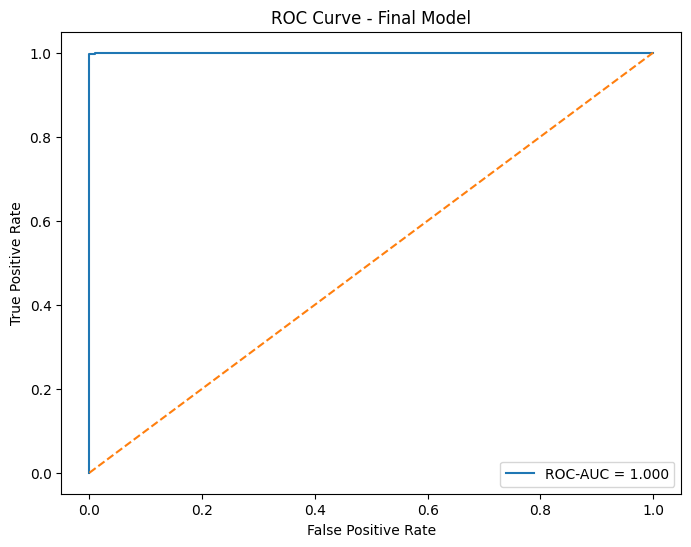

In [109]:
plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"ROC-AUC = {roc_auc_score(y_test, final_probability):.3f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve - Final Model")

plt.legend()

plt.show()

In [110]:
import joblib
import os

In [111]:
os.makedirs("../models", exist_ok=True)

In [112]:
joblib.dump(
    final_model,
    "../models/healthcare_disease_risk_model.pkl"
)

print("Final model saved successfully!")

Final model saved successfully!


In [114]:
import pandas as pd
import joblib
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [115]:
df = pd.read_csv("../data/raw/healthcare_disease_risk.csv")

print(df.shape)

(2000, 11)


In [116]:
X = df.drop("Disease_Risk", axis=1)
y = df["Disease_Risk"]

categorical_columns = X.select_dtypes(include="object").columns

X = pd.get_dummies(
    X,
    columns=categorical_columns,
    drop_first=True
)

print("Features:", X.shape)

Features: (2000, 11)


In [117]:
X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [118]:
scaler = StandardScaler()

scaler.fit(X_train_raw)

print("Scaler created successfully!")

Scaler created successfully!


In [119]:
os.makedirs("../models", exist_ok=True)

joblib.dump(
    scaler,
    "../models/healthcare_scaler.pkl"
)

print("Scaler saved successfully!")

Scaler saved successfully!


In [120]:
import os

print(
    os.path.exists(
        "../models/healthcare_scaler.pkl"
    )
)

True
